# Mortalidade: causas mais frequentes no estado

**Pergunta que este notebook responde:** quais foram as principais causas de
óbito no estado, e como se distribuem por sexo e faixa etária?

**Fonte:** SIM — Sistema de Informações sobre Mortalidade (declarações de óbito).
**Tempo estimado:** 3 a 5 minutos.

> **Atenção:** no SIM, ao contrário do CNES, **não** se passa o parâmetro
> `group` — fazer isso devolve uma tabela vazia.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"     # sigla do estado
ANO = 2023    # o SIM costuma ter 1 a 2 anos de defasagem

## Passo 1 — Conferir o que existe

In [4]:
from pysus import list_files

catalogo = list_files(dataset="sim", state=UF)
anos = sorted({int(a) for a in catalogo["year"].dropna()})

print(f"Anos disponíveis para {UF}: {anos[-10:]}")
print(f"{ANO} disponível? {'sim' if ANO in anos else 'NÃO — escolha outro ano'}")

Anos disponíveis para PR: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
2023 disponível? sim


## Passo 2 — Baixar os óbitos

Sem `group`: no SIM, passá-lo faz a função devolver zero linhas.

### ⚠️ Uma armadilha do `state=`

O parâmetro `state=` diz à PySUS **qual estado procurar**, mas ele **não filtra
o resultado**. Desde 2026 o catálogo do DATASUS publica, ao lado do arquivo de
cada estado, um arquivo **nacional** — e a PySUS devolve os dois. Somados, eles
trazem o Brasil inteiro e ainda contam o seu estado **duas vezes**.

A célula abaixo resolve isso de uma vez: fica com o arquivo do próprio estado
(o catálogo sabe distinguir — o nacional vem sem estado) e, se o ano só tiver o
arquivo nacional, filtra pelo código do IBGE e avisa que fez isso.

> Procurar a sigla no nome do arquivo **não** funciona: `DO23OPEN` contém "PE".

In [5]:
import pathlib
import pandas as pd
from pysus import list_files

CODIGO_UF = {
    "RO": "11", "AC": "12", "AM": "13", "RR": "14", "PA": "15", "AP": "16",
    "TO": "17", "MA": "21", "PI": "22", "CE": "23", "RN": "24", "PB": "25",
    "PE": "26", "AL": "27", "SE": "28", "BA": "29", "MG": "31", "ES": "32",
    "RJ": "33", "SP": "35", "PR": "41", "SC": "42", "RS": "43", "MS": "50",
    "MT": "51", "GO": "52", "DF": "53",
}


def baixar_do_estado(nome_base, funcao, uf, ano, coluna_municipio="CODMUNRES"):
    """Baixa a base e garante que só sobre o estado pedido."""
    catalogo = list_files(dataset=nome_base, state=uf, year=ano)
    do_estado = {
        pathlib.Path(str(n)).name
        for n in catalogo.loc[catalogo["state"] == uf, "name"]
    }
    caminhos = funcao(state=uf, year=ano)
    escolhidos = [p for p in caminhos if pathlib.Path(str(p)).name in do_estado]

    if escolhidos:
        df = pd.concat([pd.read_parquet(p) for p in escolhidos], ignore_index=True)
    else:
        df = pd.concat([pd.read_parquet(p) for p in caminhos], ignore_index=True)
        antes = len(df)
        df = df[df[coluna_municipio].astype(str).str[:2] == CODIGO_UF[uf]]
        print(f"  (este ano só tem arquivo nacional: filtrei {antes:,} linhas "
              f"do país para {len(df):,} de {uf})")
    return df.reset_index(drop=True)

from pysus import sim

obitos = baixar_do_estado("sim", sim, UF, ANO)

print(f"{len(obitos):,} óbitos registrados em {UF}, {ANO}")
print(f"{len(obitos.columns)} colunas disponíveis")

83,465 óbitos registrados em PR, 2023
87 colunas disponíveis


## Passo 3 — As causas mais frequentes

A causa básica do óbito está em `CAUSABAS`, no formato CID-10 (por exemplo,
`I219` = infarto agudo do miocárdio). O primeiro caractere indica o **capítulo**
da CID, que agrupa as causas por natureza.

In [6]:
import pandas as pd

top_causas = (
    obitos["CAUSABAS"]
    .value_counts()
    .head(15)
    .rename_axis("CID-10")
    .reset_index(name="Óbitos")
)

top_causas["% do total"] = (top_causas["Óbitos"] / len(obitos) * 100).round(2)
top_causas

,CID-10,Óbitos,% do total
0,I219,4047,4.85
1,J189,2919,3.50
2,I10,2447,2.93
3,G309,1984,2.38
4,I64,1955,2.34
5,C349,1935,2.32
6,E149,1616,1.94
7,J449,1371,1.64
8,J440,1327,1.59
9,I694,1326,1.59


### Agrupando por capítulo da CID-10

Uma leitura mais útil para gestão: agrupar por grande grupo de causas.

In [7]:
CAPITULOS = {
    "A": "Infecciosas e parasitárias", "B": "Infecciosas e parasitárias",
    "C": "Neoplasias", "D": "Neoplasias e doenças do sangue",
    "E": "Endócrinas e metabólicas", "F": "Transtornos mentais",
    "G": "Sistema nervoso", "H": "Olhos e ouvidos",
    "I": "Aparelho circulatório", "J": "Aparelho respiratório",
    "K": "Aparelho digestivo", "L": "Pele", "M": "Sistema osteomuscular",
    "N": "Aparelho geniturinário", "O": "Gravidez, parto e puerpério",
    "P": "Período perinatal", "Q": "Malformações congênitas",
    "R": "Sintomas e achados mal definidos",
    "S": "Lesões e traumatismos", "T": "Lesões e envenenamentos",
    "V": "Causas externas", "W": "Causas externas",
    "X": "Causas externas", "Y": "Causas externas",
}

obitos["capitulo"] = obitos["CAUSABAS"].str[0].map(CAPITULOS).fillna("Não classificado")

por_capitulo = (
    obitos["capitulo"].value_counts()
    .rename_axis("Grupo de causas")
    .reset_index(name="Óbitos")
)
por_capitulo["%"] = (por_capitulo["Óbitos"] / len(obitos) * 100).round(1)
por_capitulo.head(10)

,Grupo de causas,Óbitos,%
0,Aparelho circulatório,22083,26.5
1,Neoplasias,16334,19.6
2,Causas externas,9369,11.2
3,Aparelho respiratório,9323,11.2
4,Endócrinas e metabólicas,4909,5.9
5,Aparelho digestivo,4902,5.9
6,Sistema nervoso,4420,5.3
7,Infecciosas e parasitárias,3457,4.1
8,Aparelho geniturinário,2638,3.2
9,Sintomas e achados mal definidos,1853,2.2


## Passo 4 — Em gráfico

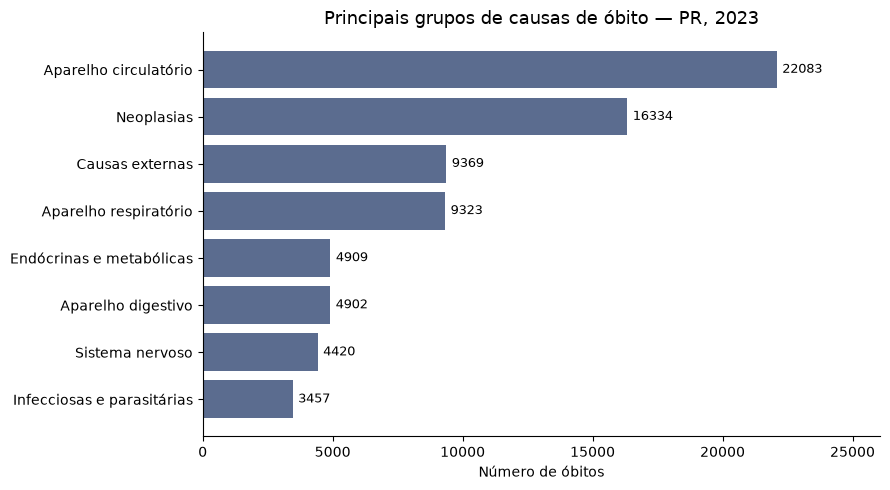

In [8]:
import matplotlib.pyplot as plt

grafico = por_capitulo.head(8).sort_values("Óbitos")

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(grafico["Grupo de causas"], grafico["Óbitos"], color="#5b6c8f")
ax.bar_label(barras, padding=4, fontsize=9)

ax.set_title(f"Principais grupos de causas de óbito — {UF}, {ANO}", fontsize=13)
ax.set_xlabel("Número de óbitos")
ax.set_xlim(0, grafico["Óbitos"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Passo 5 — Distribuição por sexo

No SIM, `SEXO` usa códigos: `1` masculino, `2` feminino, `0` ou `9` ignorado.

In [9]:
SEXOS = {"1": "Masculino", "2": "Feminino", "0": "Ignorado", "9": "Ignorado"}

por_sexo = (
    obitos["SEXO"].astype(str).map(SEXOS).fillna("Ignorado")
    .value_counts()
    .rename_axis("Sexo")
    .reset_index(name="Óbitos")
)
por_sexo["%"] = (por_sexo["Óbitos"] / len(obitos) * 100).round(1)
por_sexo

,Sexo,Óbitos,%
0,Masculino,46697,55.9
1,Feminino,36751,44.0
2,Ignorado,17,0.0


## Como adaptar

- **Outro estado ou ano:** mude `UF` e `ANO` na célula de parâmetros.
- **Um município:** filtre `CODMUNRES` (código IBGE de residência) logo após
  baixar.
- **Uma causa específica:** filtre `CAUSABAS` pelo código CID-10 de interesse —
  por exemplo, `obitos[obitos["CAUSABAS"].str.startswith("I21")]` para infarto.
- **Mortalidade infantil:** combine com o SINASC (nascidos vivos) para calcular
  a taxa por mil nascimentos.

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [10]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

conferir(1, "Vieram óbitos", len(obitos) > 0, f"{len(obitos):,} óbitos")
# CODIGO_UF e um DICIONARIO sigla -> codigo.
conferir(2, "Todos são do estado pedido",
         set(obitos["CODMUNRES"].astype(str).str[:2].unique()) == {str(CODIGO_UF[UF])}
         if "CODMUNRES" in obitos.columns else True,
         f"código {CODIGO_UF[UF]}")
# por_capitulo e DataFrame com RangeIndex: o nome esta numa COLUNA.
_col = [c for c in por_capitulo.columns if por_capitulo[c].dtype == object]
_topo = str(por_capitulo[_col[0]].iloc[0]) if _col else ""
conferir(3, "O capítulo mais frequente é plausível para o Brasil",
         "circulat" in _topo.lower() or "neoplas" in _topo.lower(),
         f"1º lugar: {_topo[:45]}")
conferir(4, "A soma dos capítulos não passa do total de óbitos",
         int(por_capitulo["Óbitos"].sum()) <= len(obitos),
         f"{int(por_capitulo['Óbitos'].sum()):,} de {len(obitos):,}")

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")

Verificações
1. Vieram óbitos — 83,465 óbitos: confere
2. Todos são do estado pedido — código 41: confere
3. O capítulo mais frequente é plausível para o Brasil — 1º lugar: Aparelho circulatório: confere
4. A soma dos capítulos não passa do total de óbitos — 83,465 de 83,465: confere
Tudo confere.


---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*